In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [30]:
from clusters_lattice_bigN import SpinConfiguration

def get_bibj(n = 24, delta = 1., lamb = 1., print_data = False):

    sc = SpinConfiguration(N = n, key = f'{n}A', delta = delta, lamb = lamb, lowest_eignstates=5, print_data = print_data, save_ham=False, force_ham_gen=False)
    #print(f'Ground state energy per spin: {round(sc.get_ground_state()[0]/(n), 5)}J')
    gs = sc.get_ground_state()[1]
    cluster_map = sc.cluster.cluster_map
    rotation_map = sc.rotation_map

    directions = [(-1, 0), (0, -1)]  # x and y directions
    flips = [sc.flips_change_side, sc.flips_change_up]  # x and y directions

    eval_bibj = 0.
    k = [0., 0.]
    easy_ks = [0., 2.]
    is_easy_k = easy_ks.__contains__(k[0]) and easy_ks.__contains__(k[1])

    for repr, state in tqdm(sc.representatives.items(), total = len(sc.representatives), disable = not print_data):
        config = sc.map_int_to_config_extended(repr)
        
        rot = (config * rotation_map + (1 - config) * (1 - rotation_map))

        for id, dir in enumerate(directions):
            roll_config = np.roll(config, dir, axis=(0, 1))
                            
            possible_mixing = np.mod((config + roll_config) * cluster_map, 2)

            config_int_shift = np.array(possible_mixing * flips[id], dtype=float)
            # multiplying to account for sign
            config_int_shift *= (-1.)**config

            for int_shift in config_int_shift[config_int_shift != 0].astype(int):
                repr_b, trans = sc.roll_to_repr(repr + int_shift)
                basis_index = sc.map_int_to_basis(repr_b)
                
                if basis_index < state:
                    phase = 1.
                    if not is_easy_k:
                        phase = np.mean([np.exp( -1j * np.pi * np.dot(k, t) ) for t in trans])
                    
                    element = 0.5 * phase * np.sqrt(sc.norms[repr]/sc.norms[repr_b])
                    
                    eval_bibj += 2 * np.real(np.conj(gs[basis_index]) * gs[state]) * element
                    #eval_bibj += np.conj(gs[basis_index]) * gs[state] * element

    eval_bibj /= n

    rotation_map = sc.rotation_map
    m_s = 0
    mag_int = 0
    
    for repr, amp in zip(sc.representatives.keys(), gs):
        config = sc.map_int_to_config(repr)
        rot = config * rotation_map + (1 - config) * (1 - rotation_map)

        m_s += np.square(np.abs(amp)) * np.sum(rot * cluster_map) / n
        mag_int += np.square(np.abs(amp)) * np.sum(rot * np.roll(rot, (0, -1), axis = (0, 1)) * cluster_map) / n
        mag_int += np.square(np.abs(amp)) * np.sum(rot * np.roll(rot, (-1, 0), axis = (0, 1)) * cluster_map) / n
    
    return eval_bibj, m_s, mag_int

In [31]:
print(get_bibj(n = 22, delta = 1., lamb = 0., print_data = False))

(np.float64(-0.22336561966182963), np.float64(0.052952346371357234), np.float64(0.04081886175835175))


In [ ]:
def disp(lamb_0 : bool = True, delta = 1., l = 0., _print = True):
    #if lamb_0:
    #    bibj, n, mag_int = get_bibj(n = 18, delta = delta, lamb = 0.)
    #else:
    #    bibj, n, mag_int = get_bibj(n = 18, delta = delta, lamb = l)
    if l == 0:
        bibj = -0.2206
        n = 0.05228
        mag_int = 0.04
    elif l == 1:
        bibj = -0.45206
        n = 0.5
        mag_int = 0.561

    bibj, n, mag_int = get_bibj(n = 20, delta = delta, lamb = l, print_data = False)
    
    #if l == 1:
    #    _, _, _ = get_bibj(n = 20, delta = delta, lamb = 1, print_data = False)

    t = -bibj

    ak = delta + t - n * (t/2 + l * delta)
    bk = 1 - 2 * n + mag_int + t * (t/2 + l * delta)

    if _print:

        try:
            print(f'Gap at G point: {2 * np.sqrt(ak**2 - bk**2)}')
        except:
            print(ak)
            print(bk)
        
        print(f'Gap at X point: {2 * np.sqrt(ak**2)}')

        print(t, n, mag_int)

    return ak, bk

disp(delta = 1, l = 0)
disp(delta = 1, l = 1)
print()
disp(delta = 2, l = 0)
disp(delta = 2, l = 1)

Gap at G point: 1.5140694212754129
Gap at X point: 2.436367029439405
0.2241535733106966 0.05326757457235816 0.03580758311576119
Gap at G point: nan
Gap at X point: 1.690807885396018
0.4605385902640138 0.5000000000000011 0.6593429450870866



/var/folders/jb/pn5t5h311zsft2cyz0gcvhj00000gn/T/ipykernel_1248/4183894345.py:28: RuntimeWarning: invalid value encountered in sqrt
  print(f'Gap at G point: {2 * np.sqrt(ak**2 - bk**2)}')


Gap at G point: 9.90012299470298
Gap at X point: 10.09926366138456
0.049693377228696635 0.0024770518668368775 0.00155344119048082
Gap at G point: 4.5197206452232095
Gap at X point: 5.099977192093757
0.06665283092260472 0.5000002040688385 0.8458164232640575


(np.float64(2.5499885960468784), np.float64(1.1813014696744029))

In [68]:
def fit_gen(delta, l, params):
    t, n, mag_int = params
    ak = delta + 2*t - n * (t + l * delta)
    bk = 1 - 2 * n + mag_int + t * (t + l * delta)

    ak = delta + (1 - n) * t - l * delta * n
    bk = ((1 - n)**2 + t**2) + l * delta * t

    gap_g = 2 * np.sqrt(max(0, ak**2 - bk**2))

    if bk - ak > 0.01:
        gap_g = 10

    return [gap_g, 2 * np.sqrt(ak**2)]

def cost(params):
    gap_g_1_0 = 1.55
    gap_x_1_0 = 2.45

    gap_g_1_1 = 0.
    gap_x_1_1 = 2.52

    gap_g_2_0 = 3.757
    gap_x_2_0 = 4.243

    gap_g_2_1 = 3.183
    gap_x_2_1 = 4.156

    num_gaps = np.array(
        [ gap_g_1_0 , gap_x_1_0 ,
        gap_g_1_1 , gap_x_1_1 ,
        gap_g_2_0 , gap_x_2_0 ,
        gap_g_2_1 , gap_x_2_1
        ]
    )

    fit_gaps = np.array(
        [ 
        *fit_gen(1, 0, params) ,
        *fit_gen(1, 1, params) ,
        *fit_gen(2, 0, params) ,
        *fit_gen(2, 1, params)
        ]
    )

    return np.sum( np.square( num_gaps - fit_gaps ) )

In [69]:
from scipy.optimize import minimize

fun = minimize(cost, [.22, .052, .05])
print(fun.x)
print(fit_gen(1, 0, fun.x))

[0.20755835 0.04527603 0.05      ]
[np.float64(1.4482676943156187), np.float64(2.3963218569664386)]


In [34]:
ns = np.arange(16, 26.001, 2, dtype = int)
lamb = 1.

n_bs = []
n_mss = []
n_mag_int = []

for n in ns:
    bibj, ms, mag_int = get_bibj(n, 1., lamb, print_data = True)
    n_bs.append(bibj)
    n_mss.append(ms)
    n_mag_int.append(mag_int)
    print(f'{n} done')

Representatives loaded successfully
Trying to read hamiltonian
No hamiltonian to read or forced to start generation.


100%|██████████| 10/10 [00:00<00:00, 20.90it/s]


Getting H took: 0.78706 s
Finding eigvals and eigvecs took: 0.00503 s


100%|██████████| 1620/1620 [00:00<00:00, 5438.80it/s]


16 done
Representatives loaded successfully
Trying to read hamiltonian
No hamiltonian to read or forced to start generation.


...

22 done
Representatives loaded successfully
Trying to read hamiltonian
Hamiltonian loaded successfully.
Finding eigvals and eigvecs took: 1.39191 s


100%|██████████| 225440/225440 [01:10<00:00, 3176.13it/s]


24 done
Representatives loaded successfully
Trying to read hamiltonian
Hamiltonian loaded successfully.
Finding eigvals and eigvecs took: 5.01813 s


100%|██████████| 800048/800048 [05:26<00:00, 2453.36it/s]


26 done


In [35]:
data_matrix = np.zeros((len(ns), 4))
data_matrix[:, 0] = ns
data_matrix[:, 1] = n_bs
data_matrix[:, 2] = n_mss
data_matrix[:, 3] = n_mag_int
np.savetxt(f'size_scaling_params_{float(lamb)}.txt', data_matrix)

In [36]:
from scipy.optimize import minimize

def fit(x, pars):
    a, b, c = pars
    return a + b * x**(5/2) + c * x**(7/2)


[4.52065468e-01 1.50000011e+01 5.87366747e-08]


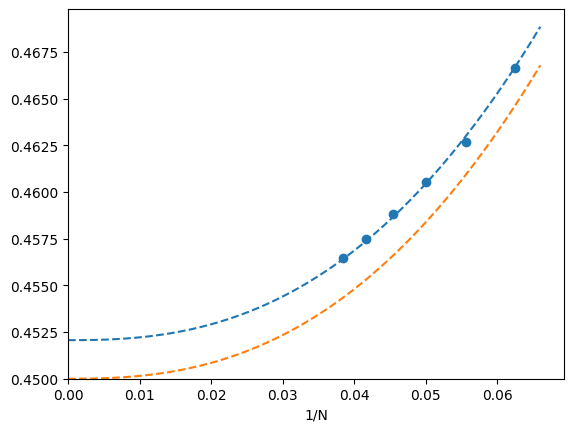

In [45]:
def cost(pars):
    return np.sum(np.square(fit(1/ns, pars) + np.array(n_bs)))

x0 = [.45, 15., 0.]
fun = minimize(cost, x0)
print(fun.x)

x = np.linspace(0, 0.066, 51)
plt.plot(x, fit(x, fun.x), ls = '--')
plt.plot(x, fit(x, x0), ls = '--')

plt.scatter(1/ns, -np.array(n_bs))
plt.xlabel('1/N')
plt.xlim([0, None])
plt.ylim([.45, None])
#plt.plot(1/ns, n_mss)
plt.show()

[0.5 0.  0. ]


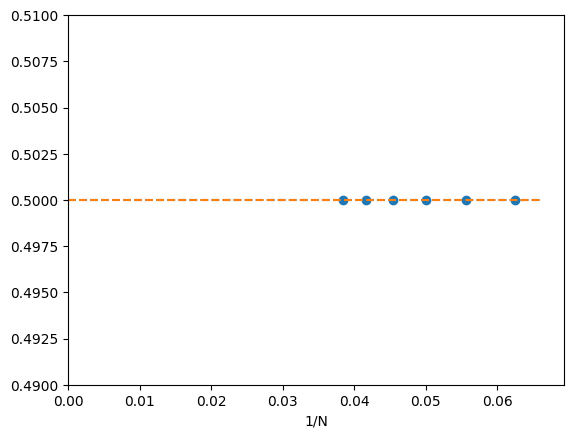

In [55]:
def fit(x, pars):
    a, b, c = pars
    return a + b * x**(9/2) + c * x**(7/2)

def cost(pars):
    return np.sum(np.square(fit(1/ns, pars) - np.array(n_mss)))

x0 = [.5, 0., 0.]
fun = minimize(cost, x0)
print(fun.x)

x = np.linspace(0, 0.066, 51)
plt.plot(x, fit(x, fun.x), ls = '--')
plt.plot(x, fit(x, x0), ls = '--')

plt.scatter(1/ns, n_mss)
plt.xlabel('1/N')
plt.xlim([0, None])
plt.ylim([.49, .51])
plt.show()

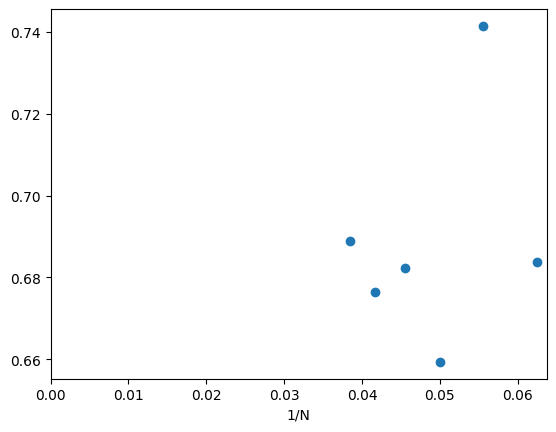

In [47]:
plt.scatter(1/ns, n_mag_int)
plt.xlabel('1/N')
plt.xlim([0, None])
plt.ylim([None, None])
plt.show()